# Synthetic Library: Parameter Estimation Example

This notebook demonstrates how to use the Synthetic library to generate ground truth data and then
estimate model parameters from sparse, real-world-like observations.

**Workflow:**
1. Build a small network model with known (ground truth) parameters
2. Simulate the full timecourse
3. Downsample to sparse timepoints (mimicking real biological experiments)
4. (Next steps) Estimate parameters from the sparse data

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from synthetic import Builder
from synthetic.Solver.ScipySolver import ScipySolver

# Figure config
FONT_SIZE = 10
MM_TO_INCHES = 1 / 25.4

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.titlesize'] = FONT_SIZE
plt.rcParams['axes.labelsize'] = FONT_SIZE
plt.rcParams['xtick.labelsize'] = FONT_SIZE
plt.rcParams['ytick.labelsize'] = FONT_SIZE
plt.rcParams['legend.fontsize'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 1

## 1. Build a Small Network Model

In [14]:
# Small network for tractability: 1 cascade at degree 1, 2 at degree 2
vc = Builder.specify(
    degree_cascades=[1, 2],
    random_seed=42,
    auto_drug=True,
)

print(f"Species: {len(vc.spec.species_list)} -> {vc.spec.species_list}")
print(f"Drug: {vc.list_drugs()[0]['name']}, targets: {vc.list_drugs()[0]['targets']}")

Species: 8 -> ['R1_1', 'I1_1', 'R2_1', 'I2_1', 'R2_2', 'I2_2', 'O', 'D']
Drug: D, targets: ['R1_1']


## 2. Simulate Ground Truth Timecourse

In [15]:
# Compile solver and simulate full timecourse
antimony = vc.model.get_antimony_model()
solver = ScipySolver()
solver.compile(antimony, jit=False)

# Dense simulation: 201 timepoints
timecourse_full = solver.simulate(start=0, stop=10000, step=201)

# Store ground truth parameters and initial conditions
true_params = vc.model.get_parameters()
true_initial = vc.model.get_state_variables()

print(f"Full timecourse: {timecourse_full.shape[0]} timepoints, {timecourse_full.shape[1] - 1} species")
print(f"Parameters: {len(true_params)}")
print(f"Time range: {timecourse_full['time'].iloc[0]} - {timecourse_full['time'].iloc[-1]}")

Full timecourse: 202 timepoints, 14 species
Parameters: 32
Time range: 0.0 - 10000.0


## 3. Downsample to Sparse Observations

Real biological experiments typically measure at far fewer timepoints than a dense simulation.
Here we pick ~10-12 timepoints spread across pre-drug, drug onset, and post-drug phases.

In [16]:
# Define sparse timepoints mimicking a real experiment
DRUG_TIME = 5000.0
sparse_times = np.array([
    # Pre-drug baseline
    0, 1000, 2000, 3500,
    # Around drug onset
    4500, 5500,
    # Post-drug response
    6000, 7000, 8000, 9000, 10000,
], dtype=float)

# Extract closest rows from the full timecourse
sparse_indices = [np.argmin(np.abs(timecourse_full['time'].values - t)) for t in sparse_times]
timecourse_sparse = timecourse_full.iloc[sparse_indices].reset_index(drop=True)

print(f"Full timecourse: {len(timecourse_full)} timepoints")
print(f"Sparse observed: {len(timecourse_sparse)} timepoints")
print(f"Sparse times: {timecourse_sparse['time'].values}")

Full timecourse: 202 timepoints
Sparse observed: 11 timepoints
Sparse times: [    0.  1000.  2000.  3500.  4500.  5500.  6000.  7000.  8000.  9000.
 10000.]


In [17]:
# Define sparse post-drug timepoints mimicking a real experiment
# We only observe after drug treatment for parameter calibration
DRUG_TIME = 5000.0
sparse_times = np.array([
    # Post-drug response only (calibration window)
    5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000,
], dtype=float)

# Extract closest rows from the full timecourse
sparse_indices = [np.argmin(np.abs(timecourse_full['time'].values - t)) for t in sparse_times]
timecourse_sparse = timecourse_full.iloc[sparse_indices].reset_index(drop=True)

print(f"Full timecourse: {len(timecourse_full)} timepoints")
print(f"Sparse observed (post-drug): {len(timecourse_sparse)} timepoints")
print(f"Sparse times: {timecourse_sparse['time'].values}")
print(f"Calibration window: t={timecourse_sparse['time'].values[0]:.0f} - {timecourse_sparse['time'].values[-1]:.0f}")

Full timecourse: 202 timepoints
Sparse observed (post-drug): 11 timepoints
Sparse times: [ 5000.  5500.  6000.  6500.  7000.  7500.  8000.  8500.  9000.  9500.
 10000.]
Calibration window: t=5000 - 10000


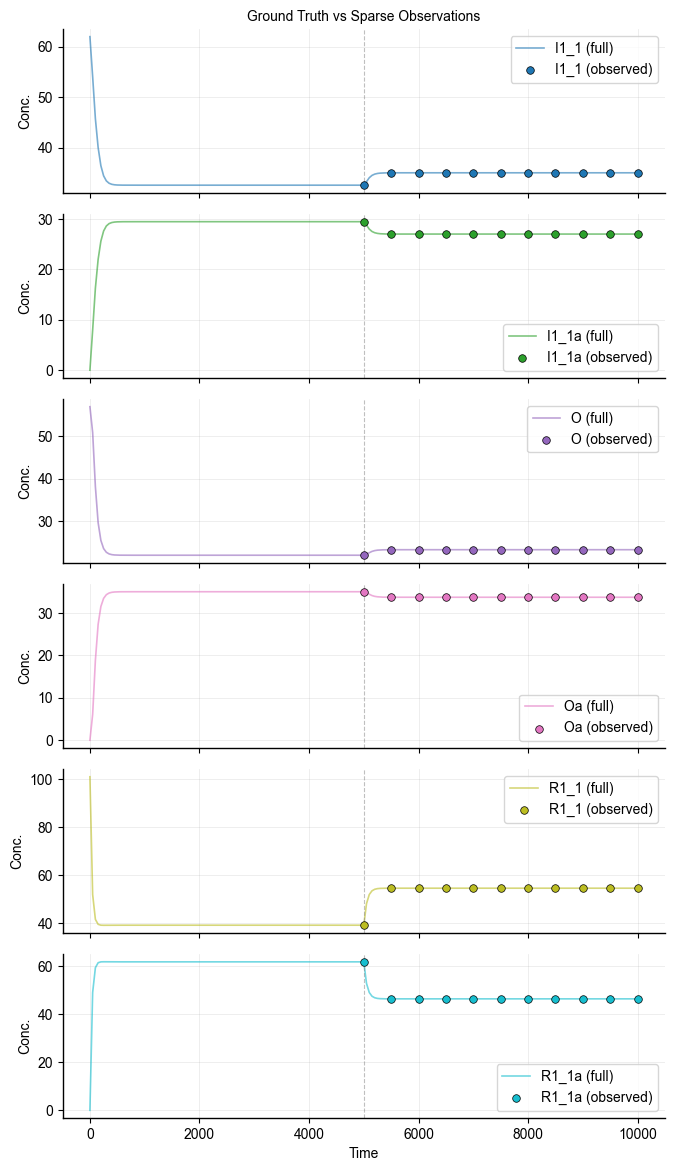

In [18]:
# Select key species to visualize
key_species = [s for s in timecourse_full.columns if s.startswith('R1') or s.startswith('I1') or s in ('O', 'Oa')]
n_species = len(key_species)

fig_width_mm = 174
fig_height_mm = 50 * n_species
fig, axes = plt.subplots(n_species, 1, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES), sharex=True)

if n_species == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, n_species))

for i, (ax, species) in enumerate(zip(axes, sorted(key_species))):
    # Full timecourse (line)
    ax.plot(timecourse_full['time'], timecourse_full[species], color=colors[i], linewidth=1.2, alpha=0.6, label=f'{species} (full)')
    # Sparse observations (scatter)
    ax.scatter(timecourse_sparse['time'], timecourse_sparse[species], color=colors[i], s=30, zorder=5, edgecolors='black', linewidths=0.5, label=f'{species} (observed)')
    ax.axvline(x=DRUG_TIME, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_ylabel('Conc.', fontsize=FONT_SIZE)
    ax.legend(loc="best", fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3, linewidth=0.5)

axes[-1].set_xlabel('Time', fontsize=FONT_SIZE)
axes[0].set_title('Ground Truth vs Sparse Observations', fontsize=FONT_SIZE)

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/param_estimation_observations.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
# Summary of data for parameter estimation
print("=" * 50)
print("Data Summary for Parameter Estimation")
print("=" * 50)
print("Network: degree_cascades=[1, 2]")
print(f"Species: {len(vc.spec.species_list)}")
print(f"Ground truth parameters: {len(true_params)}")
print(f"Full timecourse timepoints: {len(timecourse_full)}")
print(f"Sparse observed timepoints: {len(timecourse_sparse)}")
print(f"Drug onset: t={DRUG_TIME}")
print(f"Observed species: {list(timecourse_sparse.columns[1:])}")

Data Summary for Parameter Estimation
Network: degree_cascades=[1, 2]
Species: 8
Ground truth parameters: 32
Full timecourse timepoints: 202
Sparse observed timepoints: 11
Drug onset: t=5000.0
Observed species: ['I1_1', 'I1_1a', 'I2_1', 'I2_1a', 'I2_2', 'I2_2a', 'O', 'Oa', 'R1_1', 'R1_1a', 'R2_1', 'R2_1a', 'R2_2', 'R2_2a']


## 4. Parameter Estimation via Optimization

We now estimate a subset of kinetic parameters from the sparse post-drug observations using `scipy.optimize.minimize`.

**Approach:**
- Select 10-15 identifiable parameters (Km and Vmax from key reactions)
- Define an objective function that simulates the timecourse with trial parameters and computes MSE against observed data
- Optimize in log-space to enforce positivity
- Compare estimated parameters to ground truth and initial guesses

In [20]:
# Select parameters to estimate: Km and Vmax from the first 6 reactions
# These are the most identifiable parameters in typical biochemical models
all_param_names = list(true_params.keys())

# Select Km and Vmax parameters (most identifiable)
param_names = [p for p in all_param_names if p.startswith('Km_') or p.startswith('Vmax_')]
# Limit to first ~12 parameters for tractability
param_names = param_names[:12]

# True values for selected parameters
true_values = np.array([true_params[p] for p in param_names])

print(f"Total model parameters: {len(all_param_names)}")
print(f"Parameters to estimate: {len(param_names)}")
print()
for i, p in enumerate(param_names):
    print(f"  {p:15s} = {true_params[p]:.4f}")

Total model parameters: 32
Parameters to estimate: 12

  Km_J0           = 505.0000
  Vmax_J0         = 5.7196
  Km_J1           = 384.7234
  Km_J2           = 310.0000
  Vmax_J2         = 6.2205
  Km_J3           = 310.0000
  Km_J4           = 495.0000
  Vmax_J4         = 4.0186
  Km_J5           = 495.0000
  Vmax_J5         = 7.2519
  Km_J6           = 270.0000
  Vmax_J6         = 4.9847


In [21]:
from scipy.optimize import minimize

# Species to fit: all observable species (exclude drug D)
species_to_fit = [s for s in timecourse_sparse.columns if s != 'time']

# Sparse observation times
sparse_times_obs = timecourse_sparse['time'].values

def objective(log_params):
    """
    Objective function for parameter estimation.
    Simulates the model with given parameters and computes MSE
    against sparse observations at post-drug timepoints.
    """
    # Convert from log-space to linear
    trial_params = dict(zip(param_names, np.exp(log_params)))

    # Reset solver to known initial conditions
    solver.set_state_values(true_initial)
    solver.set_parameter_values(trial_params)

    try:
        tc = solver.simulate(start=0, stop=10000, step=201)
    except Exception:
        return 1e10  # penalty for failed simulation

    # Extract simulated values at sparse observation times
    sim_indices = [np.argmin(np.abs(tc['time'].values - t)) for t in sparse_times_obs]

    # Compute MSE across all observable species
    residuals = []
    for sp in species_to_fit:
        sim_vals = tc[sp].values[sim_indices]
        obs_vals = timecourse_sparse[sp].values
        residuals.append((sim_vals - obs_vals) ** 2)

    return np.mean(residuals)

print("Objective function defined.")
print(f"Fitting {len(species_to_fit)} species at {len(sparse_times_obs)} timepoints")
print(f"Estimating {len(param_names)} parameters")

Objective function defined.
Fitting 14 species at 11 timepoints
Estimating 12 parameters


In [22]:
# Generate initial guess by perturbing true values
np.random.seed(123)
perturbation_factors = np.random.uniform(0.3, 3.0, size=len(param_names))
initial_values = true_values * perturbation_factors
log_initial_guess = np.log(initial_values)

# Define bounds in log-space (2 orders of magnitude below and above true)
log_bounds = [(np.log(0.01 * tv), np.log(100.0 * tv)) for tv in true_values]

# Evaluate objective at initial guess
loss_initial = objective(log_initial_guess)
print(f"Initial guess loss (MSE): {loss_initial:.6f}")
print(f"Initial perturbation factors: {perturbation_factors.round(2)}")
print()

# Run optimization
print("Running L-BFGS-B optimization...")
result = minimize(
    objective,
    log_initial_guess,
    method='L-BFGS-B',
    bounds=log_bounds,
    options={'maxiter': 200, 'ftol': 1e-12, 'disp': True},
)

# Extract estimated parameters
estimated_values = np.exp(result.x)

print("\nOptimization result:")
print(f"  Success: {result.success}")
print(f"  Message: {result.message}")
print(f"  Iterations: {result.nit}")
print(f"  Function evaluations: {result.nfev}")
print(f"  Final loss (MSE): {result.fun:.8f}")
print(f"  Initial loss (MSE): {loss_initial:.8f}")
print(f"  Improvement: {loss_initial / result.fun:.1f}x")

Initial guess loss (MSE): 91.375696
Initial perturbation factors: [2.18 1.07 0.91 1.79 2.24 1.44 2.95 2.15 1.6  1.36 1.23 2.27]

Running L-BFGS-B optimization...


/tmp/ipykernel_487162/1386917211.py:18: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(



Optimization result:
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Iterations: 49
  Function evaluations: 897
  Final loss (MSE): 0.00001289
  Initial loss (MSE): 91.37569589
  Improvement: 7089355.6x


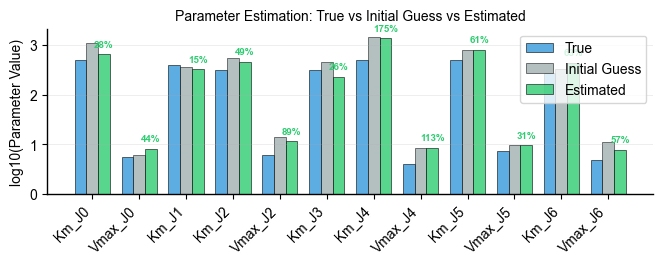

Parameter             True    Initial  Estimated  Error %
----------------------------------------------------------
Km_J0              505.000   1101.136    646.525    28.0%
Vmax_J0              5.720      6.135      8.264    44.5%
Km_J1              384.723    351.060    327.502    14.9%
Km_J2              310.000    554.450    460.531    48.6%
Vmax_J2              6.221     13.950     11.752    88.9%
Km_J3              310.000    447.140    229.171    26.1%
Km_J4              495.000   1459.291   1362.534   175.3%
Vmax_J4              4.019      8.636      8.558   113.0%
Km_J5              495.000    791.265    798.605    61.3%
Vmax_J5              7.252      9.853      9.535    31.5%
Km_J6              270.000    331.177    439.998    63.0%
Vmax_J6              4.985     11.308      7.808    56.6%


In [23]:
# Parameter comparison: True vs Initial Guess vs Estimated
fig, ax = plt.subplots(figsize=(174 * MM_TO_INCHES, 70 * MM_TO_INCHES))

x = np.arange(len(param_names))
width = 0.25

# Log-scale values for better visualization
log_true = np.log10(true_values)
log_initial = np.log10(initial_values)
log_estimated = np.log10(estimated_values)

ax.bar(x - width, log_true, width, label='True', color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x, log_initial, width, label='Initial Guess', color='#95a5a6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.bar(x + width, log_estimated, width, label='Estimated', color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=FONT_SIZE)
ax.set_ylabel('log10(Parameter Value)', fontsize=FONT_SIZE)
ax.set_title('Parameter Estimation: True vs Initial Guess vs Estimated', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, frameon=True)
ax.grid(True, alpha=0.3, axis='y', linewidth=0.5)
ax.tick_params(axis='y', labelsize=FONT_SIZE)

# Add percentage error annotations
for i in range(len(param_names)):
    pct_error = abs(estimated_values[i] - true_values[i]) / true_values[i] * 100
    ax.annotate(f'{pct_error:.0f}%', xy=(i + width, log_estimated[i]),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=7, color='#2ecc71', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('../docs/images/param_estimation_results.png', dpi=200, bbox_inches='tight')
plt.show()

# Print detailed comparison table
print(f"{'Parameter':<15} {'True':>10} {'Initial':>10} {'Estimated':>10} {'Error %':>8}")
print("-" * 58)
for i, p in enumerate(param_names):
    err = abs(estimated_values[i] - true_values[i]) / true_values[i] * 100
    print(f"{p:<15} {true_values[i]:>10.3f} {initial_values[i]:>10.3f} {estimated_values[i]:>10.3f} {err:>7.1f}%")

/tmp/ipykernel_487162/1256620927.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


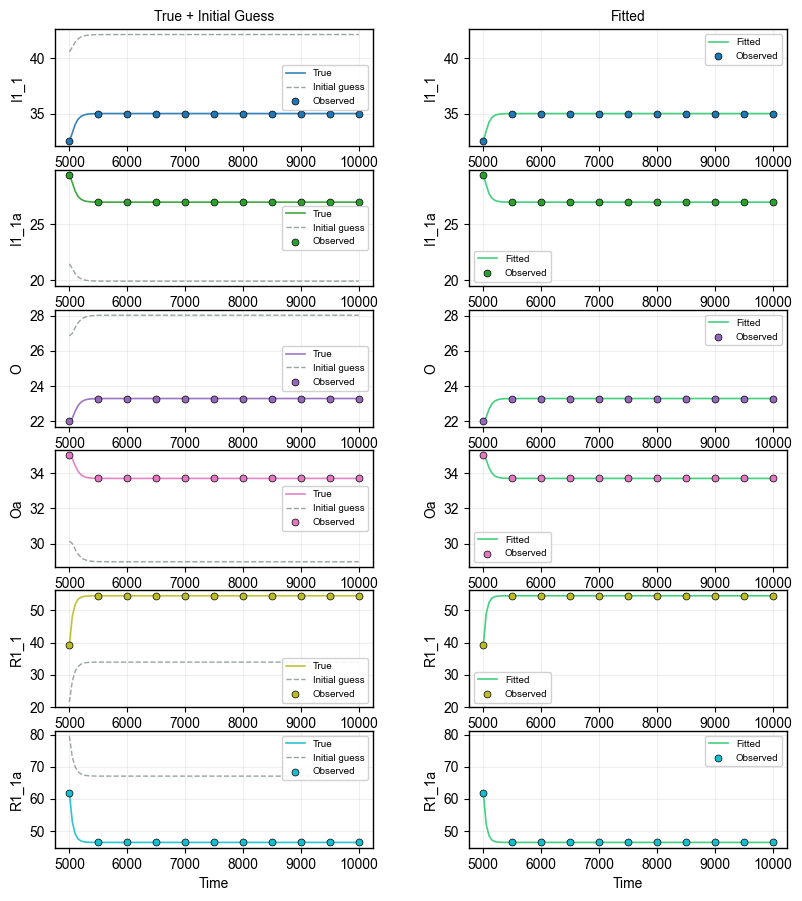

In [24]:
# Simulate with estimated parameters
solver.set_state_values(true_initial)
solver.set_parameter_values(dict(zip(param_names, estimated_values)))
timecourse_fitted = solver.simulate(start=0, stop=10000, step=201)

# Simulate with initial guess parameters
solver.set_state_values(true_initial)
solver.set_parameter_values(dict(zip(param_names, initial_values)))
timecourse_guess = solver.simulate(start=0, stop=10000, step=201)

# Plot: Side-by-side — Left: true + initial guess, Right: fitted (post-drug only)
key_species = [s for s in timecourse_full.columns if s.startswith('R1') or s.startswith('I1') or s in ('O', 'Oa')]
n_species = len(key_species)

fig_width_mm = 240
fig_height_mm = 45 * n_species
fig, axes = plt.subplots(n_species, 2, figsize=(fig_width_mm * MM_TO_INCHES, fig_height_mm * MM_TO_INCHES),
                         gridspec_kw={'wspace': 0.3})

if n_species == 1:
    axes = axes.reshape(1, -1)

colors = plt.cm.tab10(np.linspace(0, 1, n_species))

# Post-drug mask
post_drug = timecourse_full['time'] >= DRUG_TIME
post_drug_guess = timecourse_guess['time'] >= DRUG_TIME
post_drug_fitted = timecourse_fitted['time'] >= DRUG_TIME

for i, species in enumerate(sorted(key_species)):
    c = colors[i]

    # === Left panel: True + Initial guess (post-drug) ===
    ax_left = axes[i, 0]
    ax_left.plot(timecourse_full.loc[post_drug, 'time'], timecourse_full.loc[post_drug, species],
                 color=c, linewidth=1.2, alpha=0.9, label='True')
    ax_left.plot(timecourse_guess.loc[post_drug_guess, 'time'], timecourse_guess.loc[post_drug_guess, species],
                 color='#7f8c8d', linewidth=1.0, alpha=0.8, linestyle='--', label='Initial guess')
    ax_left.scatter(timecourse_sparse['time'], timecourse_sparse[species], color=c, s=25, zorder=5,
                    edgecolors='black', linewidths=0.5, label='Observed')
    ax_left.set_ylabel(species, fontsize=FONT_SIZE)
    ax_left.grid(True, alpha=0.3, linewidth=0.5)
    if i == 0:
        ax_left.set_title('True + Initial Guess', fontsize=FONT_SIZE)
    if i == n_species - 1:
        ax_left.set_xlabel('Time', fontsize=FONT_SIZE)
    ax_left.tick_params(axis='both', labelsize=FONT_SIZE)
    ax_left.legend(fontsize=7, loc='best', framealpha=0.9)

    # === Right panel: Fitted (post-drug) ===
    ax_right = axes[i, 1]
    ax_right.plot(timecourse_fitted.loc[post_drug_fitted, 'time'], timecourse_fitted.loc[post_drug_fitted, species],
                  color='#2ecc71', linewidth=1.2, alpha=0.9, label='Fitted')
    ax_right.scatter(timecourse_sparse['time'], timecourse_sparse[species], color=c, s=25, zorder=5,
                     edgecolors='black', linewidths=0.5, label='Observed')
    ax_right.set_ylabel(species, fontsize=FONT_SIZE)
    ax_right.grid(True, alpha=0.3, linewidth=0.5)
    if i == 0:
        ax_right.set_title('Fitted', fontsize=FONT_SIZE)
    if i == n_species - 1:
        ax_right.set_xlabel('Time', fontsize=FONT_SIZE)
    ax_right.tick_params(axis='both', labelsize=FONT_SIZE)
    ax_right.legend(fontsize=7, loc='best', framealpha=0.9)

    # Match y-limits between panels for easy comparison
    y_min = min(ax_left.get_ylim()[0], ax_right.get_ylim()[0])
    y_max = max(ax_left.get_ylim()[1], ax_right.get_ylim()[1])
    ax_left.set_ylim(y_min, y_max)
    ax_right.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('../docs/images/param_estimation_fitted.png', dpi=200, bbox_inches='tight')
plt.show()